In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from torch.utils.data import Dataset
import torch
from sklearn.model_selection import train_test_split

data=load_breast_cancer()
X=data['data']
Y=data['target']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3)
#X contiene 569 registros con 30 columnas
#Y contieen 569 valores de la clase

In [41]:
X.shape, Y.shape


((569, 30), (569,))

In [42]:
X[0], Y[0]

(array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01]),
 np.int64(0))

In [43]:
data=[(xi,yi) for xi, yi in zip(X_train, Y_train)]
loader_train = torch.utils.data.DataLoader(data, batch_size=19, shuffle=True)

In [44]:
xi,yi=next(iter(loader_train))
xi.shape, yi.shape

(torch.Size([19, 30]), torch.Size([19]))

In [45]:
#Modelo:
#El modelo debe tener 30 entradas. Una para cada variable
model = torch.nn.Sequential(
    torch.nn.Linear(30, 50),
    torch.nn.Dropout(p=0.1),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 30),
    torch.nn.Dropout(p=0.1),
    torch.nn.ReLU(),
    torch.nn.Linear(30, 1),
    torch.nn.Dropout(p=0.1),
    torch.nn.Sigmoid(),
    torch.nn.Flatten(0,1)
)

y=model(torch.unsqueeze(torch.tensor(X_train[1]).float(),0))
print(y, y.detach())
print(X_train[1].shape)
print(torch.unsqueeze(torch.tensor(X_train[1]).float(),0).shape)

tensor([0.5000], grad_fn=<ViewBackward0>) tensor([0.5000])
(30,)
torch.Size([1, 30])


In [46]:
learning_rate = 1e-7
#Función de error.
loss_fn=torch.nn.BCELoss() #Función adecuada para procesos de clasificación binaria
#Optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.7, weight_decay=1e-4)

In [47]:
#Proceso de entrenamiento:
errores=[]
for epoch in range(5000): #Se realizarán un total de 20000 pasadas del data set de entrenamiento
  err_tmp=[]
  for xi,yi in loader_train:
    optimizer.zero_grad()
    y_pred = model(xi.float())
    loss = loss_fn(y_pred, yi.float())
    loss.backward()
    optimizer.step()
    err_tmp.append(loss.detach().item())
  errores.append(np.mean(err_tmp))
  if(epoch % 200==0):
    #loader_train = torch.utils.data.DataLoader(datos, batch_size=100, shuffle=True)
    print('Epoch: ', epoch, ', Loss: ',errores[-1])
    #print(y_pred, yi)

Epoch:  0 , Loss:  17.01373377300444
Epoch:  200 , Loss:  6.223531683286031
Epoch:  400 , Loss:  6.589508022580828
Epoch:  600 , Loss:  4.095827888874781
Epoch:  800 , Loss:  4.4002909035909745
Epoch:  1000 , Loss:  2.2355310264087858
Epoch:  1200 , Loss:  2.513236778123038
Epoch:  1400 , Loss:  2.0198100549834117
Epoch:  1600 , Loss:  2.646171209358034
Epoch:  1800 , Loss:  2.1330331762631736
Epoch:  2000 , Loss:  2.0496389723959423
Epoch:  2200 , Loss:  1.4384897720246088
Epoch:  2400 , Loss:  1.5211721786430903
Epoch:  2600 , Loss:  1.2168505376293546
Epoch:  2800 , Loss:  1.5815820594628651
Epoch:  3000 , Loss:  1.280562991187686
Epoch:  3200 , Loss:  0.8934909843263172
Epoch:  3400 , Loss:  0.8970566874458676
Epoch:  3600 , Loss:  0.9226412503492265
Epoch:  3800 , Loss:  1.1012088656425476
Epoch:  4000 , Loss:  0.8184255602813902
Epoch:  4200 , Loss:  0.8864063656046277
Epoch:  4400 , Loss:  0.7610088671956744
Epoch:  4600 , Loss:  0.8244969007514772
Epoch:  4800 , Loss:  0.804556

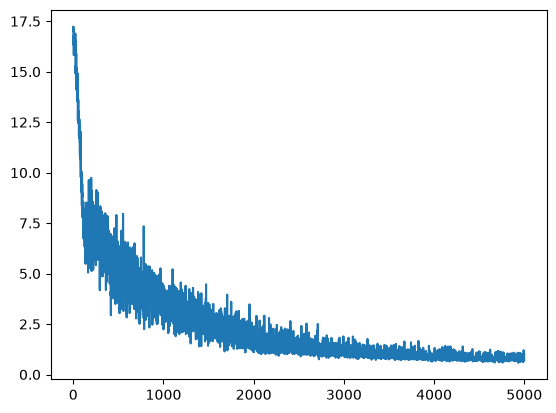

In [48]:
plt.plot(errores)


In [49]:
#Verificación de la red para la predicción
#Proceso de entrenamiento:
data=[(xi,yi) for xi, yi in zip(X_test, Y_test)]
loader_test = torch.utils.data.DataLoader(data, batch_size=19, shuffle=True)
pred, real=[],[]
model.eval()
for xi,yi in loader_test:
  y_pred = model(xi.float()).detach().numpy()
  pred+=list(y_pred)
  real+=list(yi.numpy())


In [50]:
for re, pr in zip(real, pred):
  print(re, pr)

1 0.661263
0 0.15675066
1 0.83312654
1 0.8441888
1 0.84077084
0 0.0017382404
1 0.603301
1 0.7190185
1 0.5744538
1 0.6563254
0 0.26375893
1 0.7869717
0 0.03446011
1 0.7195338
0 0.27949437
1 0.8885281
1 0.7296056
0 0.15760955
1 0.66482306
1 0.8235399
1 0.60519844
1 0.76522726
1 0.70540845
1 0.7700799
1 0.74160546
0 0.5727343
1 0.53669196
0 0.024769295
1 0.8783857
1 0.810804
1 0.9134888
1 0.64717436
1 0.6173587
1 0.8279707
1 0.8201371
1 0.69940645
0 0.83254653
1 0.7141711
0 0.00067896035
1 0.8627051
1 0.8408325
1 0.7430871
1 0.8441734
0 0.103939176
1 0.8482575
1 0.85189134
1 0.51926196
0 0.22500667
0 0.08400606
0 0.03485332
1 0.74665916
1 0.47244614
0 0.0153768025
0 0.23700412
1 0.7173062
1 0.7488525
1 0.86306405
0 0.84781146
1 0.59746253
1 0.8266241
0 0.27565297
1 0.6919911
1 0.7626573
0 0.009970995
1 0.33729088
0 0.00023763414
1 0.5620331
0 0.23509371
0 0.04701695
0 7.447068e-05
1 0.78451467
0 0.32822925
1 0.8960104
1 0.66685575
0 0.76679593
1 0.75930285
1 0.55497175
0 0.11852992
1 0.82

Text(0.09090909090909091, 0.9137931034482759, '0.5865362286567688')

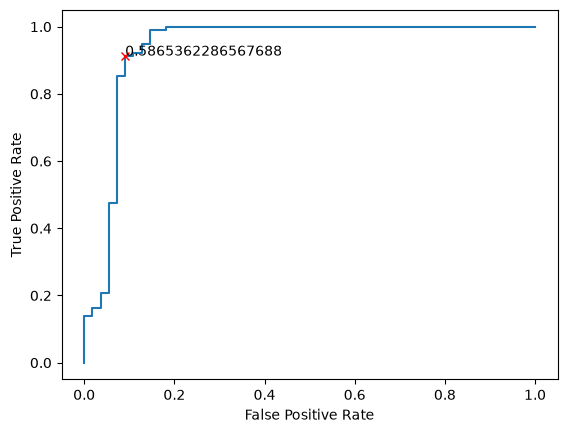

In [51]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds=roc_curve([int(r) for r in real], pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
d=(tpr-(1-fpr))**2
#plt.figure()
#plt.plot(d)
i=np.argmin(d)
plt.plot(fpr[i], tpr[i],'xr')
plt.text(fpr[i], tpr[i],str(thresholds[i]))